### Master Seminar Physical Geography 2026
## Elevational Temperature Gradient and seasonal variability in Greenland 2010-2026
#### Lea Pietrek & Miriam Erdler
---
#### 💡 Aim of the Project: characterize how elevational temperature gradients across Greenland have evolved using PROMICE Station Pairs


---
---

## Settings

In [6]:
# install necessary libraries
#!pip install pandas numpy matplotlib seaborn scipy pymannkendall jupyter

In [29]:
# import necessary libraries
import pandas as pd #reading and manipulating data
import numpy as np #numerical operations
from pathlib import Path #handling file paths
import pymannkendall as mk #Mann-Kendall trend test
import matplotlib.patches as mpatches #for legend
import matplotlib.pyplot as plt #plotting
from scipy import stats #for linear regression
import matplotlib.lines as mlines #for legend

## Part A: Data Cleaning

#### Defining constants

Paths: This section defines all folder paths used in the workflow. Using relative paths instead of local paths ensures that the notebook can be executed on different computers without modifying the code

In [8]:
# Define paths 

# project root = current folder
PROJECT_ROOT = Path.cwd()

# paths
RAW_DATA = PROJECT_ROOT / "Data" / "Data_RAW"

PROCESSED_DATA = PROJECT_ROOT / "Data" / "Data_Processed"

CLEAN_DATA = PROCESSED_DATA / "Cleaned_Stations"

FIGURE_DIR     = PROJECT_ROOT / "Figures"

RESULTS_DIR    = PROJECT_ROOT / "Results"

# create folders if they don't exist yet 
CLEAN_DATA.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
# Define constants for seasons
SEASONS = ["DJF", "MAM", "JJA", "SON"]

# Map month to season
SEASON_MAP = {
    1:"DJF", 2:"DJF", 3:"MAM", 4:"MAM",  5:"MAM",
    6:"JJA", 7:"JJA", 8:"JJA", 9:"SON", 10:"SON",
    11:"SON", 12:"DJF"
}

In [10]:
# Function to convert p-value to significance stars
def stars(p):
    """Return significance stars for a p-value."""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

Let's insepct the data! This code will check for the existing CSV Files.

In [11]:
# List all CSV files in the raw data directory
# The workflow is designed to automatically detect all PROMICE station files, 
# making it scalable and reducing the need for manual file selection.

csv_files = list(RAW_DATA.glob("*.csv"))

print(f"Found {len(csv_files)} CSV files")

for file in csv_files:
    print(file.name)

Found 18 CSV files
KAN_L_month.csv
KAN_U_month.csv
KPC_L_month.csv
KPC_U_month.csv
NUK_L_month.csv
NUK_U_month.csv
QAS_L_month.csv
QAS_U_month.csv
SCO_L_month.csv
SCO_U_month.csv
TAS_L_month.csv
TAS_U_month.csv
THU_L_month.csv
THU_U_month.csv
UPE_L_month.csv
UPE_U_month.csv
ZAC_L_month.csv
ZAC_U_month.csv


Let's continue inspecting the data and have a closer look at the dataframe

In [12]:
# Read a sample file to check the structure

sample_file = csv_files[0]

df = pd.read_csv(sample_file)

df.head()

,time,p_u,t_u,rh_u,rh_u_wrt_ice_or_water,qh_u,wspd_u,wdir_u,wspd_x_u,wspd_y_u,...,gps_alt,lat,lon,alt,batt_v,t_rad,t_i,rh_i_wrt_ice_or_water,wdir_i,wspd_y_i
0,2008-09-01,923.9882,-2.5934,79.9399,81.6629,2.8476,3.3134,133.9854,1.8320,-1.7682,...,676.17,67.097312,-49.931913,678.73,13.45,-2.0476,-2.5962,81.6650,134.9669,-1.7649
1,2008-10-01,924.2335,-8.8390,76.7142,81.4251,1.8167,4.5009,136.0388,2.4764,-2.5678,...,675.85,67.097292,-49.932110,678.70,13.25,-8.9245,-8.8353,82.3774,134.6686,-2.6032
2,2008-11-01,924.7323,-10.8112,81.3601,88.1435,1.6097,4.3467,133.9104,2.3021,-2.2162,...,674.28,67.097272,-49.932309,678.66,12.82,-11.2204,-10.8295,88.6081,131.1321,-2.2228
3,2008-12-01,916.8134,-15.4373,71.2094,78.6264,1.0833,5.7925,140.0709,3.3923,-4.0529,...,670.38,67.097251,-49.932509,678.63,12.55,-15.9078,-15.4285,83.5962,140.3030,-3.9943
4,2009-01-01,912.9546,-13.5028,62.6707,68.1504,1.1081,5.3631,129.9273,3.7522,-3.1404,...,678.00,67.097231,-49.932711,678.60,12.55,-14.0442,-13.4724,73.9714,124.2769,-3.1638


In [13]:
# Check column names
df.columns

Index(['time', 'p_u', 't_u', 'rh_u', 'rh_u_wrt_ice_or_water', 'qh_u', 'wspd_u',
       'wdir_u', 'wspd_x_u', 'wspd_y_u', 'dsr', 'dsr_cor', 'usr', 'usr_cor',
       'albedo', 'dlr', 'ulr', 'cc', 't_surf', 'dlhf_u', 'dshf_u', 'z_boom_u',
       'z_boom_cor_u', 'z_stake', 'z_stake_cor', 'z_pt', 'z_pt_cor',
       'z_surf_combined', 'z_ice_surf', 'snow_height', 'rainfall_u',
       'rainfall_cor_u', 't_i_1', 't_i_2', 't_i_3', 't_i_4', 't_i_5', 't_i_6',
       't_i_7', 't_i_8', 'd_t_i_1', 'd_t_i_2', 'd_t_i_3', 'd_t_i_4', 'd_t_i_5',
       'd_t_i_6', 'd_t_i_7', 'd_t_i_8', 't_i_10m', 'tilt_x', 'tilt_y', 'rot',
       'gps_lat', 'gps_lon', 'gps_alt', 'lat', 'lon', 'alt', 'batt_v', 't_rad',
       't_i', 'rh_i_wrt_ice_or_water', 'wdir_i', 'wspd_y_i'],
      dtype='str')

##### Extract Metadata from File Names:
PROMICE file names contain important metadata information.
Example:

`KAN_L_month.csv`

From this naming structure we extract:
- station ID (`KAN`)
- station level (`L` = lower station, `U` = upper station)
- temporal resolution (`month`)
  
This metadata will later help identify station pairs and distinguish between elevation levels.

This function extracts these three pieces of information automatically from any filename,
so the code works for all 18 files without manual input.

In [14]:
# Function to extract station information from file name
def extract_station_info(file_path):
    """
    KAN_L_month.csv → ("KAN", "L", "month")
    """
    parts = file_path.stem.split("_")
    return parts[0], parts[1], parts[2]

### Define Cleaning Function
This function applies all cleaning steps to a single PROMICE station file.

**Steps performed:**
1. Extract station metadata from the filename
2. Load the raw CSV file
3. Replace PROMICE no-data codes (`-999`, `-9999`) with `NaN`
4. Keep only the columns relevant for this analysis
5. Parse the `time` column as a proper datetime format
6. Filter rows to the study period 2010–2026
7. Replace physically impossible temperatures with `NaN`
   (values outside –70°C to +30°C cannot occur in Greenland)
8. Remove duplicate rows and sort chronologically
9. Add metadata columns (`station_id`, `site`, `position`, `resolution`)
10. Add a season label to each row (DJF / MAM / JJA / SON)

In [15]:
# Function to clean one PROMICE file
def clean_promice_file(file_path):
    """
    Load and clean one raw PROMICE CSV.
    Always reads from RAW_DATA — never modifies the original file.
    """
    station_id, station_level, temporal_resolution = extract_station_info(file_path)

    # Load raw file
    df = pd.read_csv(file_path)

    # Replace PROMICE no-data codes with NaN
    df = df.replace([-999, -9999], np.nan)

    # Keep only columns needed for analysis
    columns_to_keep = ["time", "gps_lat", "gps_lon", "gps_alt", "t_u", "rh_u"]
    df = df[[c for c in columns_to_keep if c in df.columns]]

    # Parse time as datetime
    df["time"] = pd.to_datetime(df["time"])

    # Filter to study period 2010–2026
    df = df[df["time"].dt.year.between(2010, 2026)]

    # Remove physically impossible temperatures
    if "t_u" in df.columns:
        df.loc[~df["t_u"].between(-70, 30), "t_u"] = np.nan

    # Remove duplicates, sort by time
    df = df.drop_duplicates().sort_values("time").reset_index(drop=True)

    # Add metadata from filename
    df["station_id"] = f"{station_id}_{station_level}"
    df["site"]       = station_id
    df["position"]   = station_level
    df["resolution"] = temporal_resolution
    df["season"]     = df["time"].dt.month.map(SEASON_MAP)



    return df

### Clean and Save All 18 Station Files
The cleaning function is applied to every raw file automatically.

Each cleaned file is saved individually to `Data_Processed/Cleaned_Stations/`
using the same naming structure as the raw file, with `_clean` added.

Example: `KAN_L_month.csv` → `KAN_L_month_clean.csv`

In [16]:
# Apply cleaning to every raw file and save to Cleaned_Stations 
# The output file name is derived from the input file name, with a "_clean" suffix for clarity.
for file in csv_files:

    df = clean_promice_file(file)

    station_id, station_level, temporal_resolution = extract_station_info(file)

    out_name = f"{station_id}_{station_level}_{temporal_resolution}_clean.csv"
    df.to_csv(CLEAN_DATA / out_name, index=False)

    print(f"  {file.name:25s} → {len(df):3d} rows | t_u NaN: {df['t_u'].isna().sum()}")

  KAN_L_month.csv           → 196 rows | t_u NaN: 1
  KAN_U_month.csv           → 196 rows | t_u NaN: 12
  KPC_L_month.csv           → 195 rows | t_u NaN: 54
  KPC_U_month.csv           → 195 rows | t_u NaN: 30
  NUK_L_month.csv           → 190 rows | t_u NaN: 32
  NUK_U_month.csv           → 196 rows | t_u NaN: 21
  QAS_L_month.csv           → 196 rows | t_u NaN: 7
  QAS_U_month.csv           → 196 rows | t_u NaN: 33
  SCO_L_month.csv           → 195 rows | t_u NaN: 13
  SCO_U_month.csv           → 196 rows | t_u NaN: 29
  TAS_L_month.csv           → 195 rows | t_u NaN: 59
  TAS_U_month.csv           →  68 rows | t_u NaN: 14
  THU_L_month.csv           → 181 rows | t_u NaN: 40
  THU_U_month.csv           → 181 rows | t_u NaN: 14
  UPE_L_month.csv           → 195 rows | t_u NaN: 18
  UPE_U_month.csv           → 195 rows | t_u NaN: 27
  ZAC_L_month.csv           → 196 rows | t_u NaN: 23
  ZAC_U_month.csv           → 192 rows | t_u NaN: 53


##### Data Quality Check

In [17]:
# Show % missing per variable per station
missing = {}

for file in sorted(CLEAN_DATA.glob("*.csv")):
    df = pd.read_csv(file)
    missing[file.stem] = df.isna().mean() * 100

pd.DataFrame(missing).round(1)

,KAN_L_month_clean,KAN_U_month_clean,KPC_L_month_clean,KPC_U_month_clean,NUK_L_month_clean,NUK_U_month_clean,QAS_L_month_clean,QAS_U_month_clean,SCO_L_month_clean,SCO_U_month_clean,TAS_L_month_clean,TAS_U_month_clean,THU_L_month_clean,THU_U_month_clean,UPE_L_month_clean,UPE_U_month_clean,ZAC_L_month_clean,ZAC_U_month_clean
time,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gps_lat,18.9,35.2,25.6,17.9,15.3,11.2,13.8,25.5,45.1,80.1,52.8,64.7,49.2,54.1,11.3,20.5,8.2,66.7
gps_lon,18.9,36.7,25.6,17.9,16.3,11.2,13.8,25.5,45.1,80.1,52.8,64.7,49.2,54.1,11.3,20.5,8.2,66.7
gps_alt,18.9,35.2,25.6,17.9,15.3,11.2,12.8,25.0,45.1,80.1,52.8,64.7,49.2,54.1,11.3,21.0,8.2,66.7
t_u,0.5,6.1,27.7,15.4,16.8,10.7,3.6,16.8,6.7,14.8,30.3,20.6,22.1,7.7,9.2,13.8,11.7,27.6
rh_u,5.6,3.6,25.1,12.8,23.2,6.6,2.0,18.4,1.5,10.2,24.1,14.7,20.4,3.9,7.7,10.3,6.1,25.0
station_id,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
site,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
position,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
resolution,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# ── Load all cleaned files ─────────────────────────────────────────────────────
all_stations = pd.concat(
    [pd.read_csv(f, parse_dates=["time"]) for f in sorted(CLEAN_DATA.glob("*.csv"))],
    ignore_index=True
)

Fixed elevation per station: The GPS value is not always the same resulting in noisy values for the analysis; furthermore, sometimes GPS values are missing in some months leading to NA, even tho temperature has been measured. 

To fix this issue, we applied a fixed mean elevation per station instead of teh row-by-row GPS value. 

In [19]:
# Compute fixed elevation per station 
# gps_alt is recorded row-by-row but can be noisy or missing (e.g. SCO)
# using the median across all available readings gives a stable reference elevation
elev_upper = (all_stations[all_stations["position"] == "U"]
              .groupby("site")["gps_alt"]
              .median()
              .rename("elev_upper_fixed"))

elev_lower = (all_stations[all_stations["position"] == "L"]
              .groupby("site")["gps_alt"]
              .median()
              .rename("elev_lower_fixed"))

print("\nFixed elevations per site (m a.s.l.):")
print(pd.concat([elev_upper, elev_lower], axis=1).round(1))


Fixed elevations per site (m a.s.l.):
      elev_upper_fixed  elev_lower_fixed
site                                    
KAN             1840.6             671.0
KPC              866.4             365.8
NUK             1119.0             522.9
QAS              891.4             270.7
SCO              973.8             462.7
TAS              569.6             241.5
THU              746.0             565.0
UPE              932.9             211.3
ZAC              867.2             637.1


## Build Stations Pairs + compute Temperature Gradient

In [20]:
# Build station pairs 
upper = all_stations[all_stations["position"] == "U"]
lower = all_stations[all_stations["position"] == "L"]

pairs = pd.merge(
    upper, lower,
    on=["site", "time", "season", "resolution"],
    suffixes=("_upper", "_lower")
)

# Merge fixed elevations and compute gradient 
# fixed elevations replace noisy row-by-row GPS for the gradient calculation
pairs = pairs.merge(elev_upper, on="site")
pairs = pairs.merge(elev_lower, on="site")

pairs["elev_diff_m"] = pairs["elev_upper_fixed"] - pairs["elev_lower_fixed"]

# temperature gradient in °C per 100m — main analysis variable
pairs["gradient_per100m"] = (
    (pairs["t_u_upper"] - pairs["t_u_lower"]) / pairs["elev_diff_m"]
) * 100

# drop only rows where temperature is NaN (not where GPS was NaN)
pairs = pairs.dropna(subset=["gradient_per100m"])

print(f"\n✅ {len(pairs)} paired records | {pairs['site'].nunique()} station pairs")
print(pairs.groupby("site")["gradient_per100m"].agg(["count", "mean"]).round(3))



✅ 1251 paired records | 9 station pairs
      count   mean
site              
KAN     184 -0.713
KPC     134 -0.749
NUK     147 -0.687
QAS     163 -0.751
SCO     164 -0.488
TAS      31 -0.568
THU     136 -0.880
UPE     167 -0.511
ZAC     125 -0.282


Save the final station pairs

In [21]:
# Save — this is the only file the analysis section needs
out_path = PROCESSED_DATA / "station_pairs_monthly.csv"
pairs.to_csv(out_path, index=False)
print(f"\n✅ Saved: {out_path.name}")


✅ Saved: station_pairs_monthly.csv


## Part B: Temperature Analysis

#### 💡 This Part of the Code focuses on the main analysis of the temperature data - looking at seasonality & computing statistical tests

The first analysis will examine the temperature gradient for each station and run a Mann-Kendall Test as well as Sen Slope to check wethere there are significant trends!

In [22]:
results = []

for site, grp in pairs.groupby("site"):
    # sort chronologically and drop missing gradient values
    series = grp.sort_values("time")["gradient_per100m"].dropna()

    # run Mann-Kendall
    res = mk.original_test(series)

    results.append({
        "site"           : site,
        "n"              : len(series),
        "trend"          : res.trend,       # "increasing" / "decreasing" / "no trend"
        "tau"            : round(res.Tau, 3),
        "p_value"        : round(res.p, 4),
        "sen_slope_month": round(res.slope, 6),        # °C/100m per month
        "sen_slope_year" : round(res.slope * 12, 5),   # easier to interpret
    })

# ── Results table ──────────────────────────────────────────────────────────────
mk_df = pd.DataFrame(results)
print(mk_df.to_string(index=False))

site   n      trend    tau  p_value  sen_slope_month  sen_slope_year
 KAN 184 decreasing -0.100   0.0437        -0.000479        -0.00575
 KPC 134   no trend -0.065   0.2679        -0.000420        -0.00504
 NUK 147   no trend -0.049   0.3802        -0.000304        -0.00365
 QAS 163   no trend -0.071   0.1783        -0.000536        -0.00643
 SCO 164 decreasing -0.212   0.0001        -0.001226        -0.01471
 TAS  31   no trend -0.166   0.1965        -0.006758        -0.08110
 THU 136 decreasing -0.418   0.0000        -0.004886        -0.05863
 UPE 167   no trend  0.011   0.8269         0.000077         0.00092
 ZAC 125   no trend -0.015   0.8012        -0.000171        -0.00205


### Seasonal variability

This part will have a look at the seasonal variability of the temperature gradient for each station. Once again, Mann-Kendall and Sen Slop will give us information about the significance and trend!

In [23]:
results = []

for site, grp in pairs.groupby("site"):
    for season in SEASONS:
        # filter to this season and drop NaN
        series = (grp[grp["season"] == season]
                  .sort_values("time")["gradient_per100m"]
                  .dropna())

        # skip if too few observations (< 10 = unreliable)
        if len(series) < 10:
            print(f"  {site} {season}: skipped (n={len(series)})")
            continue

        res = mk.original_test(series)

        results.append({
            "site"           : site,
            "season"         : season,
            "n"              : len(series),
            "trend"          : res.trend,
            "tau"            : round(res.Tau, 3),
            "p_value"        : round(res.p, 4),
            "sen_slope_month": round(res.slope, 6),
            "sen_slope_year" : round(res.slope * 12, 5),
        })

seasonal_df = pd.DataFrame(results)


  TAS DJF: skipped (n=8)
  TAS MAM: skipped (n=9)
  TAS JJA: skipped (n=6)
  TAS SON: skipped (n=8)


In [24]:
## Clean seasonal summary table with explicit MK and Sen Slope labels
# Build a multi-level summary table 

seasonal_df["sig"] = seasonal_df["p_value"].apply(stars) 

rows = []

for _, row in seasonal_df.iterrows():
    rows.append({
        "site"   : row["site"],
        "season" : row["season"],
        "MK trend"     : row["trend"],           # Mann-Kendall result
        "MK p-value"   : row["p_value"],         # Mann-Kendall p-value
        "MK sig"       : row["sig"],             # significance stars
        "Sen slope\n(°C/100m/yr)": row["sen_slope_year"],  # Sen's Slope rate
    })

detail_df = pd.DataFrame(rows)

# Print per season for clarity 
for season in SEASONS:
    print(f"\n{'─'*60}")
    print(f"Season: {season}")
    print(f"{'─'*60}")
    sub = detail_df[detail_df["season"] == season].drop(columns="season")
    print(sub.to_string(index=False))

print("\nMann-Kendall: tests WHETHER a trend exists (p-value + direction)")
print("Sen's Slope:  measures HOW FAST it changes (°C/100m/year)")


────────────────────────────────────────────────────────────
Season: DJF
────────────────────────────────────────────────────────────
site   MK trend  MK p-value MK sig  Sen slope\n(°C/100m/yr)
 KAN decreasing      0.0471      *                 -0.04559
 KPC   no trend      0.5317   n.s.                 -0.02823
 NUK decreasing      0.0163      *                 -0.08966
 QAS decreasing      0.0165      *                 -0.04327
 SCO   no trend      0.1803   n.s.                 -0.03380
 THU decreasing      0.0000    ***                 -0.43621
 UPE   no trend      0.8650   n.s.                 -0.01173
 ZAC   no trend      0.7744   n.s.                 -0.02227

────────────────────────────────────────────────────────────
Season: MAM
────────────────────────────────────────────────────────────
site   MK trend  MK p-value MK sig  Sen slope\n(°C/100m/yr)
 KAN   no trend      0.6466   n.s.                 -0.00658
 KPC   no trend      0.4753   n.s.                 -0.02996
 NUK   no 

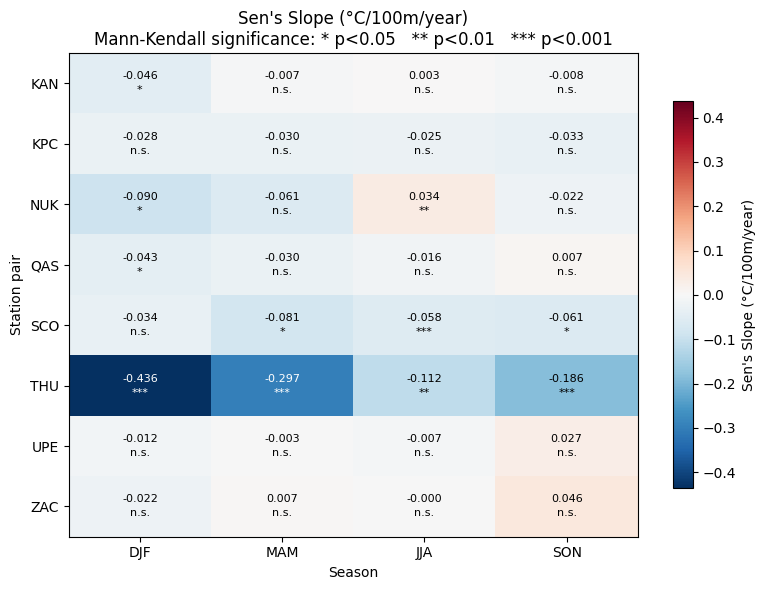

✅ Saved: seasonal_senslope_heatmap.png


In [25]:
# Pivot Sen's slope and p-values to wide format 
slope_pivot = seasonal_df.pivot(index="site", columns="season", 
                                values="sen_slope_year")[SEASONS]
pval_pivot  = seasonal_df.pivot(index="site", columns="season", 
                                values="p_value")[SEASONS]

# Plot 
fig, ax = plt.subplots(figsize=(8, 6))

# diverging colormap centered at 0 — blue = decreasing, red = increasing
vmax = np.abs(slope_pivot.values).max()
im = ax.imshow(slope_pivot.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")

# Axis labels
ax.set_xticks(range(len(SEASONS)))
ax.set_xticklabels(SEASONS)
ax.set_yticks(range(len(slope_pivot.index)))
ax.set_yticklabels(slope_pivot.index)
ax.set_xlabel("Season")
ax.set_ylabel("Station pair")
ax.set_title("Sen's Slope (°C/100m/year)\nMann-Kendall significance: * p<0.05   ** p<0.01   *** p<0.001")

# Annotate each cell with slope value + significance stars
for i, site in enumerate(slope_pivot.index):
    for j, season in enumerate(SEASONS):
        slope = slope_pivot.loc[site, season]
        p     = pval_pivot.loc[site, season]

        # significance stars from MK
        sig = stars(p)

        # choose text color based on background darkness
        text_color = "white" if abs(slope) > vmax * 0.5 else "black"

        # slope value on top line, stars on bottom
        ax.text(j, i, f"{slope:.3f}\n{sig}",
                ha="center", va="center",
                fontsize=8, color=text_color, linespacing=1.5)

# Colorbar 
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Sen's Slope (°C/100m/year)")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "seasonal_senslope_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: seasonal_senslope_heatmap.png")

------

### Seasonality: Differ DJF and JJA significantly from each other​

In [32]:
pairs = pd.read_csv(PROCESSED_DATA / "station_pairs_monthly.csv", parse_dates=["time"])

results = []

for site, grp in pairs.groupby("site"):
    djf = grp[grp["season"] == "DJF"]["gradient_per100m"].dropna().values
    jja = grp[grp["season"] == "JJA"]["gradient_per100m"].dropna().values

    # Wilcoxon signed-rank requires equal length paired samples
    # use the shorter length to pair them
    n = min(len(djf), len(jja))

    if n < 5:
        print(f"  {site}: skipped (n={n})")
        continue

    stat, p = stats.wilcoxon(djf[:n], jja[:n])

    results.append({
        "site"       : site,
        "n_paired"   : n,
        "median_DJF" : round(np.median(djf), 4),
        "median_JJA" : round(np.median(jja), 4),
        "difference" : round(np.median(djf) - np.median(jja), 4),
        "W_stat"     : round(stat, 2),
        "p_value"    : round(p, 4),
        "sig"        : stars(p),
    })

wilcoxon_df = pd.DataFrame(results)

# ── Print results ──────────────────────────────────────────────────────────────
print("Wilcoxon Signed-Rank Test: DJF vs JJA gradient")
print("Negative difference = DJF gradient more negative than JJA = steeper in winter")
print()
print(wilcoxon_df.to_string(index=False))

# Save

wilcoxon_df.to_csv(RESULTS_DIR / "wilcoxon_djf_jja.csv", index=False)
print("✅ Saved: Results/wilcoxon_djf_jja.csv")

Wilcoxon Signed-Rank Test: DJF vs JJA gradient
Negative difference = DJF gradient more negative than JJA = steeper in winter

site  n_paired  median_DJF  median_JJA  difference  W_stat  p_value  sig
 KAN        45     -0.7974     -0.5361     -0.2614    52.0   0.0000  ***
 KPC        27     -0.8087     -0.6452     -0.1635    30.0   0.0000  ***
 NUK        34     -0.7505     -0.5161     -0.2344     4.0   0.0000  ***
 QAS        39     -0.9839     -0.4490     -0.5348    32.0   0.0000  ***
 SCO        40     -0.5550     -0.3582     -0.1968    48.0   0.0000  ***
 TAS         6     -0.7901     -0.3183     -0.4719     0.0   0.0312    *
 THU        27     -0.8237     -0.6853     -0.1385    72.0   0.0039   **
 UPE        37     -0.5399     -0.4532     -0.0867   268.0   0.2132 n.s.
 ZAC        26     -0.1537     -0.4642      0.3105     4.0   0.0000  ***
✅ Saved: Results/wilcoxon_djf_jja.csv


Plotting the resulst from the Wilcoxon signed rank test for seasonality

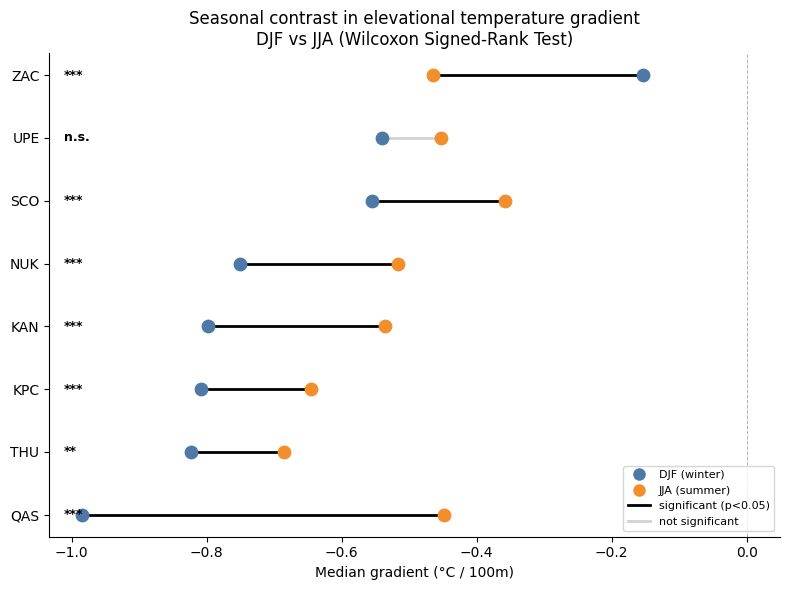

✅ Saved: dumbbell_djf_jja.png


In [34]:
PROJECT_ROOT   = Path.cwd()
PROCESSED_DATA = PROJECT_ROOT / "Data" / "Data_Processed"
RESULTS_DIR    = PROJECT_ROOT / "Results"
FIGURE_DIR     = PROJECT_ROOT / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ──────────────────────────────────────────────────────────────────
pairs        = pd.read_csv(PROCESSED_DATA / "station_pairs_monthly.csv", parse_dates=["time"])
wilcoxon_df  = pd.read_csv(RESULTS_DIR / "wilcoxon_djf_jja.csv")
# exclude TAS — insufficient paired observations (n=6)
wilcoxon_df = wilcoxon_df[wilcoxon_df["site"] != "TAS"].reset_index(drop=True)
# ── Colors ─────────────────────────────────────────────────────────────────────
COLOR_DJF = "#4e79a7"   # blue = winter
COLOR_JJA = "#f28e2b"   # orange = summer
COLOR_SIG = "black"     # significant connecting line
COLOR_NS  = "lightgrey" # non-significant connecting line

# ── Sort stations by DJF median for clean ordering ────────────────────────────
wilcoxon_df = wilcoxon_df.sort_values("median_DJF", ascending=True).reset_index(drop=True)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for i, row in wilcoxon_df.iterrows():

    # line color based on significance
    line_color = COLOR_SIG if row["sig"] != "n.s." else COLOR_NS

    # connecting line between DJF and JJA dot
    ax.plot([row["median_DJF"], row["median_JJA"]],
            [i, i],
            color=line_color, linewidth=2, zorder=1)

    # DJF dot
    ax.scatter(row["median_DJF"], i,
               color=COLOR_DJF, s=80, zorder=3)

    # JJA dot
    ax.scatter(row["median_JJA"], i,
               color=COLOR_JJA, s=80, zorder=3)

    # significance stars to the right of the plot
    ax.text(0.02, i, row["sig"],
            transform=ax.get_yaxis_transform(),
            ha="left", va="center", fontsize=9, fontweight="bold")

# ── Axis formatting ────────────────────────────────────────────────────────────
ax.set_yticks(range(len(wilcoxon_df)))
ax.set_yticklabels(wilcoxon_df["site"])
ax.set_xlabel("Median gradient (°C / 100m)")
ax.set_title("Seasonal contrast in elevational temperature gradient\nDJF vs JJA (Wilcoxon Signed-Rank Test)")

# 0°C reference line
ax.axvline(0, color="grey", linewidth=0.7, linestyle="--", alpha=0.6)

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_djf = mlines.Line2D([], [], color=COLOR_DJF, marker="o",
                            linestyle="None", markersize=8, label="DJF (winter)")
legend_jja = mlines.Line2D([], [], color=COLOR_JJA, marker="o",
                            linestyle="None", markersize=8, label="JJA (summer)")
legend_sig = mlines.Line2D([], [], color=COLOR_SIG, linewidth=2,
                            label="significant (p<0.05)")
legend_ns  = mlines.Line2D([], [], color=COLOR_NS, linewidth=2,
                            label="not significant")

ax.legend(handles=[legend_djf, legend_jja, legend_sig, legend_ns],
          fontsize=8, loc="lower right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "dumbbell_djf_jja.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: dumbbell_djf_jja.png")